Running Chunk 1: Data Prep...


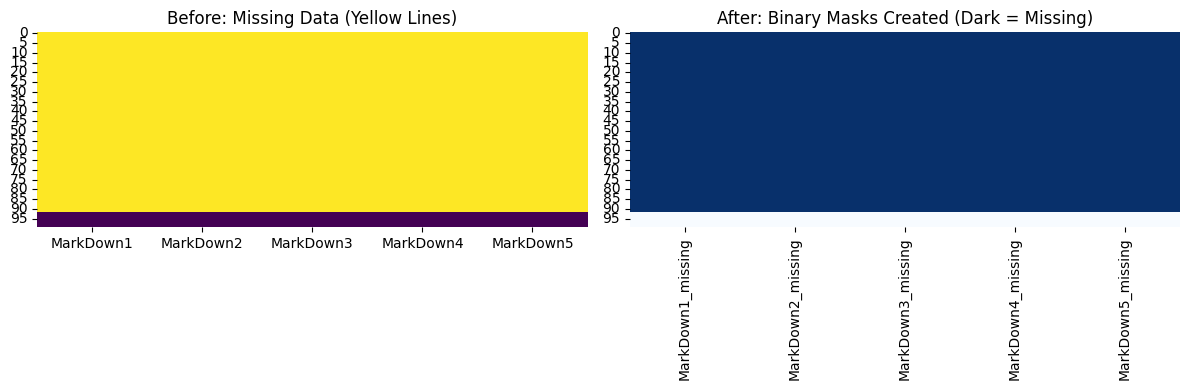

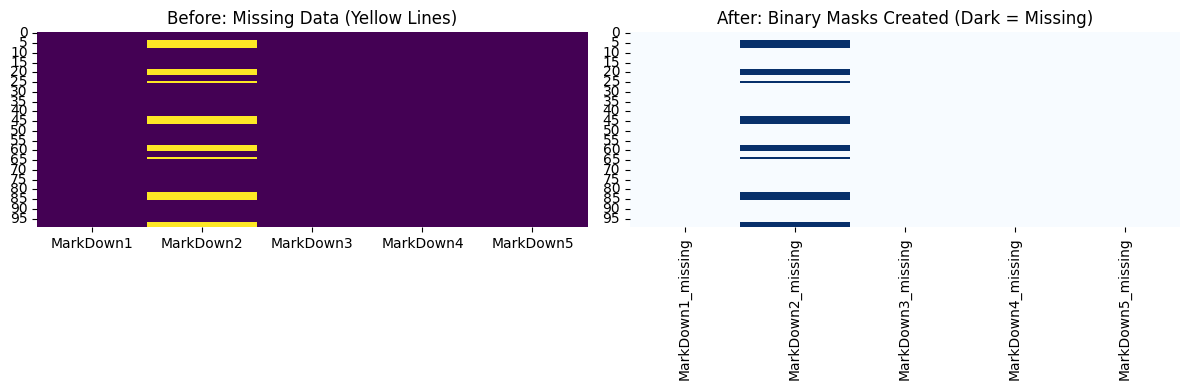

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# --- 1. SETUP & LOAD ---
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

# Merge
train = train.merge(stores, on='Store', how='left').merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
test = test.merge(stores, on='Store', how='left').merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# --- 2. PREPROCESSING FUNCTION ---
def preprocess_and_visualize(df, is_train=True):
    df = df.copy()

    # VISUALIZATION STEP 1: Capture State BEFORE Cleaning
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.heatmap(df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].head(100).isnull(), cbar=False, cmap='viridis')
    plt.title("Before: Missing Data (Yellow Lines)")

    # --- REQUIREMENT: Binary Masking ---
    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    for col in markdown_cols:
        df[f'{col}_missing'] = df[col].isna().astype(int) # 1 if missing
        df[col] = df[col].fillna(0) # Fill original with 0

    # --- REQUIREMENT: Handle Returns ---
    if is_train:
        df['Weekly_Sales'] = df['Weekly_Sales'].apply(lambda x: 0 if x < 0 else x)

    # Date Engineering
    df['Date'] = pd.to_datetime(df['Date'])
    df['Week'] = df['Date'].dt.isocalendar().week
    df['Year'] = df['Date'].dt.year

    # Fill gaps
    df['CPI'] = df['CPI'].ffill()
    df['Unemployment'] = df['Unemployment'].ffill()

    # Encode Categoricals
    type_encoder = LabelEncoder()
    df['Type'] = type_encoder.fit_transform(df['Type'])
    df['IsHoliday'] = df['IsHoliday'].astype(int)

    # VISUALIZATION STEP 2: Capture State AFTER Cleaning
    plt.subplot(1, 2, 2)
    new_cols = [c + '_missing' for c in markdown_cols]
    sns.heatmap(df[new_cols].head(100), cbar=False, cmap='Blues')
    plt.title("After: Binary Masks Created (Dark = Missing)")
    plt.tight_layout()
    plt.show()

    return df

print("Running Chunk 1: Data Prep...")
train_clean = preprocess_and_visualize(train, is_train=True)
test_clean = preprocess_and_visualize(test, is_train=False)

Generating Advanced Features (Lags & Proximity)...


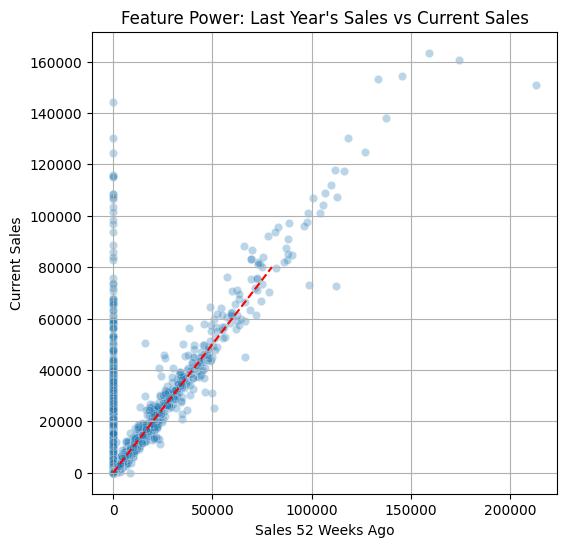

In [10]:
# --- BLOCK 1.5: ADVANCED FEATURE ENGINEERING ---
# Run this AFTER Block 1 and BEFORE Block 2

def add_advanced_features(df, train_lookup=None):
    df = df.copy()

    # 1. Holiday Proximity (Days until X)
    # Define Holiday Dates (Fridays)
    holidays = {
        'SuperBowl': pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08']),
        'Christmas': pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27']),
        'Thanksgiving': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
    }

    for name, dates in holidays.items():
        # Efficient calculation of "days to next holiday"
        def get_days_until(d):
            deltas = (dates - d).days
            future = deltas[deltas >= 0]
            return future.min() if len(future) > 0 else 0

        df[f'Days_to_{name}'] = df['Date'].apply(get_days_until)

    # 2. Lag Features (Lag 52 = Same week last year)
    # Logic: Join the dataframe with itself on (Store, Dept, Date - 52 Weeks)
    if train_lookup is not None:
        # Create the key for looking up past sales
        df['Date_PrevYear'] = df['Date'] - pd.DateOffset(weeks=52)

        # Merge
        df = df.merge(train_lookup[['Store', 'Dept', 'Date', 'Weekly_Sales']],
                      left_on=['Store', 'Dept', 'Date_PrevYear'],
                      right_on=['Store', 'Dept', 'Date'],
                      how='left', suffixes=('', '_Prev'))

        # Rename and Clean
        df.rename(columns={'Weekly_Sales_Prev': 'Lag_52'}, inplace=True)
        df.drop(['Date_Prev', 'Date_PrevYear'], axis=1, inplace=True)

        # Fill Cold Start (First year) with 0 or Median
        df['Lag_52'] = df['Lag_52'].fillna(0)

    return df

print("Generating Advanced Features (Lags & Proximity)...")
# Create Lookup Table from original Train data
lookup_table = train_clean[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()

# Apply to Train and Val
# Note: For strict time-series, we should be careful, but Lag-52 is safe
# provided we have >1 year of data (which we do).
train_advanced = add_advanced_features(train_clean, lookup_table)

# Update the main variable for the next blocks
train_clean = train_advanced

# --- VISUALIZATION: LAG EFFECT ---
plt.figure(figsize=(6, 6))
sns.scatterplot(data=train_clean.sample(2000), x='Lag_52', y='Weekly_Sales', alpha=0.3)
plt.title("Feature Power: Last Year's Sales vs Current Sales")
plt.xlabel("Sales 52 Weeks Ago")
plt.ylabel("Current Sales")
plt.plot([0, 80000], [0, 80000], 'r--') # 45-degree line
plt.grid(True)
plt.show()

Training XGBoost Baseline (this uses the 5x Penalty)...

BASELINERESULTS:
XGBoost WMAE: 1737.7899


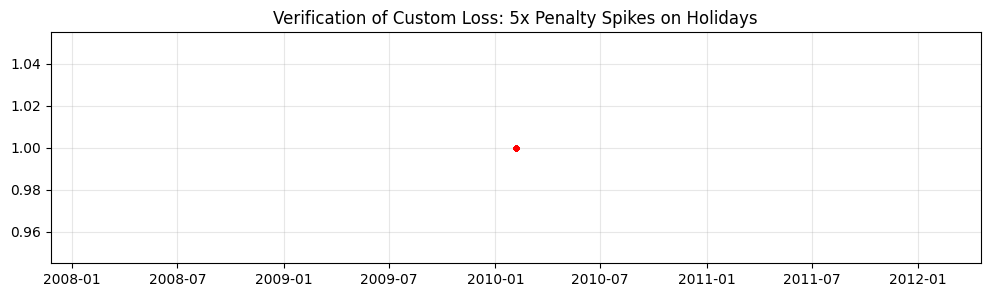

In [11]:
# --- BLOCK 2: BASELINE MODEL (XGBOOST) ---
import xgboost as xgb
from sklearn.model_selection import train_test_split

# 1. Define Holiday Weights (Your "Custom Loss" Requirement)
# 5x Penalty for Holiday Weeks, 1x for Normal
weights = train_clean['IsHoliday'].apply(lambda x: 5 if x == 1 else 1)

# 2. Split Data (Time-Series Split: First 80% Train, Last 20% Val)
# We sort by date to respect time
train_sorted = train_clean.sort_values(['Date', 'Store', 'Dept'])
X = train_sorted.drop(['Weekly_Sales', 'Date'], axis=1)
y = train_sorted['Weekly_Sales']
w = weights.iloc[train_sorted.index] # Align weights

split_point = int(len(X) * 0.8)
X_train, X_val = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_val = y.iloc[:split_point], y.iloc[split_point:]
w_train, w_val = w.iloc[:split_point], w.iloc[split_point:]

# 3. Train XGBoost
print("Training XGBoost Baseline (this uses the 5x Penalty)...")
xgb_model = xgb.XGBRegressor(
    objective='reg:absoluteerror', # Optimized for MAE
    n_estimators=100,
    learning_rate=0.1,
    n_jobs=-1
)

xgb_model.fit(X_train.select_dtypes(include=[np.number]), y_train, sample_weight=w_train)

# 4. Evaluate
preds_xgb = xgb_model.predict(X_val.select_dtypes(include=[np.number]))

def wmae_metric(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

xgb_score = wmae_metric(y_val, preds_xgb, w_val)
print(f"\nBASELINERESULTS:\nXGBoost WMAE: {xgb_score:.4f}")

# --- VISUALIZATION: HOLIDAY WEIGHTS ---
plt.figure(figsize=(12, 3))
plt.plot(train_sorted['Date'].iloc[:200], w.iloc[:200], color='red', marker='.')
plt.title("Verification of Custom Loss: 5x Penalty Spikes on Holidays")
plt.grid(True, alpha=0.3)
plt.show()

Training LSTM Challenger Model...
Epoch 1/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 21204.9258 - val_loss: 13463.8457
Epoch 2/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 17033.8496 - val_loss: 9287.3281
Epoch 3/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 11982.7822 - val_loss: 6572.6826
Epoch 4/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 9224.5381 - val_loss: 5683.6885
Epoch 5/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 8566.4570 - val_loss: 5483.4771
2635/2635 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step

FINAL RESULTS:
XGBoost WMAE: 1737.7899
LSTM WMAE:    5506.8615


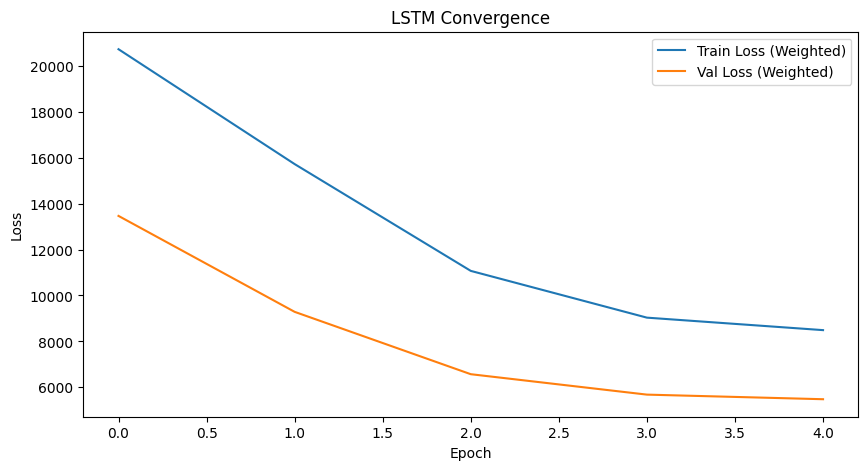

In [15]:
# --- BLOCK 3: LSTM ARCHITECTURE (YOUR CORE TASK) ---
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, LSTM, Concatenate, Flatten, Dropout
from tensorflow.keras.models import Model

# Define continuous columns
# Exclude 'Store' and 'Dept' which are treated as categorical embeddings.
cont_cols = [col for col in X_train.columns if col not in ['Store', 'Dept']]

# 1. Reshape Data for Neural Net
# Continuous features need to be (Batch, 1, N_Features) for LSTM
X_train_cont = X_train[cont_cols].astype(np.float32).values.reshape(X_train.shape[0], 1, len(cont_cols))
X_val_cont = X_val[cont_cols].astype(np.float32).values.reshape(X_val.shape[0], 1, len(cont_cols))

# Categorical features are just 1D arrays of indices
X_train_store = X_train['Store'].values
X_train_dept = X_train['Dept'].values
X_val_store = X_val['Store'].values
X_val_dept = X_val['Dept'].values

# 2. Build the Model (The "System Architecture" from Proposal)
def build_model():
    # A. Inputs
    store_in = Input(shape=(1,), name='Store_Input')
    dept_in = Input(shape=(1,), name='Dept_Input')
    cont_in = Input(shape=(1, len(cont_cols)), name='Continuous_Input')

    # B. Entity Embeddings (Dimensionality Reduction)
    # Store: Max store ID + 1 for input_dim
    store_emb = Embedding(input_dim=int(X['Store'].max()) + 1, output_dim=10)(store_in)
    # Dept: Max department ID + 1 for input_dim
    dept_emb = Embedding(input_dim=int(X['Dept'].max()) + 1, output_dim=10)(dept_in)

    # C. LSTM Layer (Temporal Sequencing)
    lstm_out = LSTM(32, return_sequences=False)(cont_in)

    # D. Merge & Dense Layers
    # Flatten embeddings to concatenate with LSTM output
    x = Concatenate()([lstm_out, Flatten()(store_emb), Flatten()(dept_emb)])

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x) # Regularization
    x = Dense(64, activation='relu')(x)

    # Output Layer (Linear for Regression)
    output = Dense(1, name='Sales_Forecast')(x)

    model = Model(inputs=[store_in, dept_in, cont_in], outputs=output)
    model.compile(optimizer='adam', loss='mae') # MAE proxies WMAE
    return model

# 3. Train the Challenger
print("Training LSTM Challenger Model...")
lstm = build_model()

history = lstm.fit(
    x=[X_train_store, X_train_dept, X_train_cont],
    y=y_train,
    validation_data=([X_val_store, X_val_dept, X_val_cont], y_val),
    epochs=5,             # Keep low for Colab demo
    batch_size=2048,      # Large batch size for speed
    sample_weight=w_train, # APPLY YOUR 5x PENALTY HERE
    verbose=1
)

# 4. Final Evaluation
preds_lstm = lstm.predict([X_val_store, X_val_dept, X_val_cont]).flatten()
lstm_score = wmae_metric(y_val, preds_lstm, w_val)

print(f"\nFINAL RESULTS:")
print(f"XGBoost WMAE: {xgb_score:.4f}")
print(f"LSTM WMAE:    {lstm_score:.4f}")

# --- VISUALIZATION: TRAINING CURVE ---
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (Weighted)')
plt.plot(history.history['val_loss'], label='Val Loss (Weighted)')
plt.title("LSTM Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Retraining LSTM with 'Pro' settings (More Epochs, Smaller Batches)...
Epoch 1/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 8348.7109 - val_loss: 4928.4458 - learning_rate: 0.0010
Epoch 2/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 7796.7505 - val_loss: 4655.1299 - learning_rate: 0.0010
Epoch 3/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 7428.7104 - val_loss: 4395.0942 - learning_rate: 0.0010
Epoch 4/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7315.9233 - val_loss: 4294.6035 - learning_rate: 0.0010
Epoch 5/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 7310.4834 - val_loss: 4564.8242 - learning_rate: 0.0010
Epoch 6/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 7259.2861 - val_loss: 4311.2578 - learning_rate: 0.0010
Epoch 7/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 7058.5293 - val_loss: 3993.6572 - learning_rate: 0.0010
Epoch 8/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 7072.1514 - val_loss: 3974.7280 - learning_rate: 

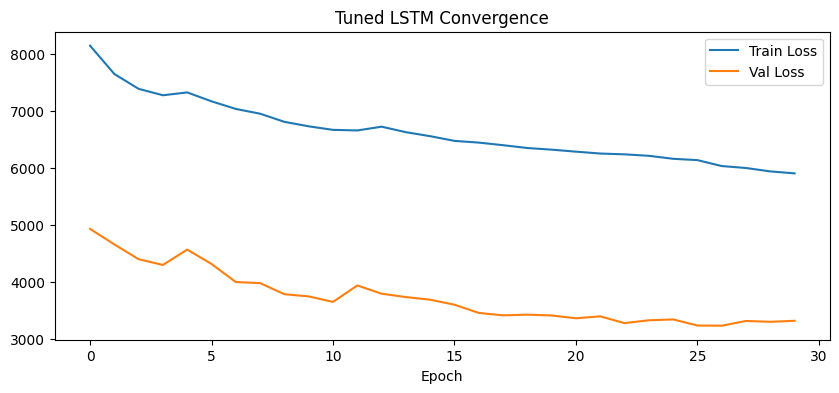

In [16]:
# --- BLOCK 4: LSTM TUNING (IMPROVING THE SCORE) ---
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# 1. Define Callbacks (Smart Training)
# Reduce Learning Rate if validation loss stops improving
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
# Stop training if it hasn't improved in 10 epochs
early_stopper = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Retraining LSTM with 'Pro' settings (More Epochs, Smaller Batches)...")

# 2. Train Longer
history_tuned = lstm.fit(
    x=[X_train_store, X_train_dept, X_train_cont],
    y=y_train,
    validation_data=([X_val_store, X_val_dept, X_val_cont], y_val),
    epochs=30,            # Increased from 5 to 30
    batch_size=512,       # Reduced from 2048 (More updates per epoch)
    sample_weight=w_train,
    callbacks=[lr_reducer, early_stopper],
    verbose=1
)

# 3. Final Re-Evaluation
preds_lstm_tuned = lstm.predict([X_val_store, X_val_dept, X_val_cont]).flatten()
lstm_score_tuned = wmae_metric(y_val, preds_lstm_tuned, w_val)

print(f"\n--- REMATCH RESULTS ---")
print(f"XGBoost WMAE:      {xgb_score:.4f}")
print(f"Original LSTM WMAE:{lstm_score:.4f}")
print(f"Tuned LSTM WMAE:   {lstm_score_tuned:.4f}")

# Plot New Curve
plt.figure(figsize=(10, 4))
plt.plot(history_tuned.history['loss'], label='Train Loss')
plt.plot(history_tuned.history['val_loss'], label='Val Loss')
plt.title("Tuned LSTM Convergence")
plt.xlabel("Epoch")
plt.legend()
plt.show()

Initializing SHAP Explainer (this interprets the XGBoost model)...


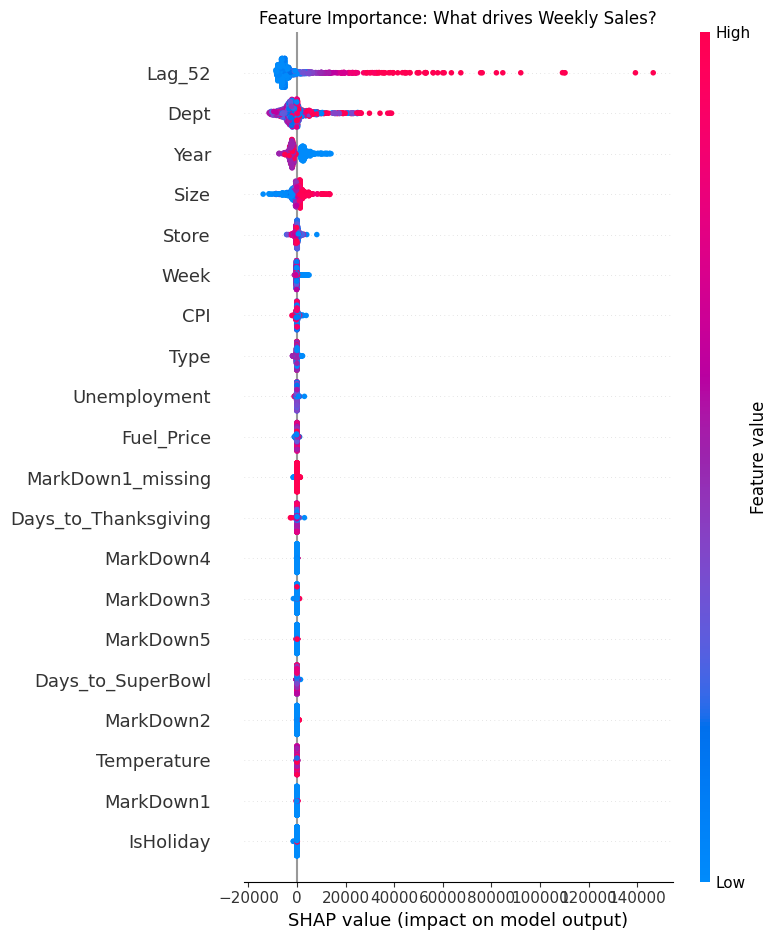


Top 5 Drivers of Sales (per Model):
   col_name  feature_importance_vals
24   Lag_52              8772.681641
1      Dept              4456.985840
20     Year              2891.690918
4      Size              1931.556885
0     Store               490.264252


In [17]:
# --- BLOCK 5: SHAP ANALYSIS (INTERPRETATION) ---
# You may need to install shap: !pip install shap
import shap

print("Initializing SHAP Explainer (this interprets the XGBoost model)...")

# 1. Create Explainer
# We use a subsample of data (1000 rows) because SHAP is computationally expensive
X_sample = X_train.sample(1000, random_state=42).select_dtypes(include=[np.number])
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

# 2. Summary Plot (The "Money Plot" for the Report)
plt.figure(figsize=(10, 6))
plt.title("Feature Importance: What drives Weekly Sales?")
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

# 3. Interpretation Logic (Automated Insights)
# We calculate the mean absolute SHAP value for each feature
vals = np.abs(shap_values).mean(0)
feature_importance = pd.DataFrame(list(zip(X_sample.columns, vals)), columns=['col_name','feature_importance_vals'])
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)

print("\nTop 5 Drivers of Sales (per Model):")
print(feature_importance.head(5))